In [3]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os
import urllib.request
from pathlib import Path

if IN_COLAB:
    drive.mount('/content/drive')
    # Shared project folder (one-time: open folder → Add shortcut to Drive)
    DRIVE_BASE = '/content/drive/.shortcut-targets-by-id/1r4t5aR-3Yal45Gv94bZEj7Pulyx3iLl1/CSC-566-Final_Project_Mel_Spectrograms'
    METADATA_DIR = f'{DRIVE_BASE}/metadata'
    MELSPECS_DIR = f'{DRIVE_BASE}/melspecs'
    LOCAL_MELSPECS = '/content/melspecs'
else:
    PROJECT_ROOT = Path('..').resolve()
    METADATA_DIR = str(PROJECT_ROOT / 'data' / 'metadata')
    MELSPECS_DIR = str(PROJECT_ROOT / 'data' / 'melspecs')
    LOCAL_MELSPECS = MELSPECS_DIR

os.makedirs(LOCAL_MELSPECS, exist_ok=True)

TSV_PATH = f'{METADATA_DIR}/autotagging_moodtheme.tsv'
if not os.path.exists(TSV_PATH):
    fallback_meta = '/content/metadata' if IN_COLAB else METADATA_DIR
    os.makedirs(fallback_meta, exist_ok=True)
    TSV_PATH = f'{fallback_meta}/autotagging_moodtheme.tsv'
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/MTG/mtg-jamendo-dataset/master/data/autotagging_moodtheme.tsv',
        TSV_PATH,
    )

if not os.path.isdir(MELSPECS_DIR):
    print(f'WARNING: {MELSPECS_DIR} not found.')
    print('Add the shared project folder to Drive: https://drive.google.com/drive/folders/1r4t5aR-3Yal45Gv94bZEj7Pulyx3iLl1')
elif not os.path.exists(TSV_PATH):
    print(f'WARNING: {TSV_PATH} not found.')
else:
    n_mels = len([f for f in os.listdir(MELSPECS_DIR) if f.endswith('.npy')])
    print('Drive mounted and metadata found. Ready to go.')
    print(f'Melspec files on Drive: {n_mels}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and metadata found. Ready to go.
Melspec files on Drive: 13880


In [4]:
if IN_COLAB:
    !pip install librosa -q

import numpy as np
import librosa.display
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

In [5]:
import shutil
from concurrent.futures import ThreadPoolExecutor

MAX_TRACKS = 5000

if IN_COLAB:
    files = [f for f in os.listdir(MELSPECS_DIR) if f.endswith('.npy')][:MAX_TRACKS]
    print(f'Copying {len(files)} files...')

    def copy_file(fname):
        src = os.path.join(MELSPECS_DIR, fname)
        dst = os.path.join(LOCAL_MELSPECS, fname)
        if not os.path.exists(dst):
            shutil.copy(src, dst)

    with ThreadPoolExecutor(max_workers=8) as executor:
        list(tqdm(executor.map(copy_file, files), total=len(files), desc='Copying'))

print(f'Done! Files available: {len([f for f in os.listdir(LOCAL_MELSPECS) if f.endswith(".npy")])}')

Copying 5000 files...


Copying: 100%|██████████| 5000/5000 [08:19<00:00, 10.01it/s]

Done! Files available: 5000


In [6]:
# Check for corrupted .npy files and remove them from both local and Drive
bad_files = []
for fname in os.listdir(LOCAL_MELSPECS):
    if not fname.endswith(".npy"):
        continue
    local_path = os.path.join(LOCAL_MELSPECS, fname)
    try:
        np.load(local_path, mmap_mode="r")
    except Exception as e:
        print(f"Bad: {fname} — {e}")
        bad_files.append(fname)

print(f"{len(bad_files)} corrupted files found.")
for fname in bad_files:
    os.remove(os.path.join(LOCAL_MELSPECS, fname))
    drive_path = os.path.join(MELSPECS_DIR, fname)
    if os.path.exists(drive_path):
        os.remove(drive_path)
    print(f"Deleted: {fname}")

if bad_files:
    print("Re-run the download cell to re-fetch corrupted files.")
else:
    print("All files OK.")


0 corrupted files found.
All files OK.


In [7]:
import pandas as pd

# MOOD/THEME TSV
rows = []
with open(TSV_PATH) as f:
    next(f)  # skip header
    for line in f:
        parts = line.rstrip('\n').split('\t')
        rows.append({
            'TRACK_ID':  parts[0],
            'ARTIST_ID': parts[1],
            'ALBUM_ID':  parts[2],
            'PATH':      parts[3],
            'DURATION':  float(parts[4]),
            'TAGS_MOOD': parts[5:],  # all remaining fields are tags
        })

df = pd.DataFrame(rows)
df.head()

,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS_MOOD
0,track_0000948,artist_000087,album_000149,48/948.mp3,212.7,[mood/theme---background]
1,track_0000950,artist_000087,album_000149,50/950.mp3,248.0,[mood/theme---background]
2,track_0000951,artist_000087,album_000149,51/951.mp3,199.7,[mood/theme---background]
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,[mood/theme---film]
4,track_0002263,artist_000320,album_000366,63/2263.mp3,494.7,[mood/theme---melancholic]


In [8]:
exploded_tags = df.explode('TAGS_MOOD')
tag_counts = exploded_tags['TAGS_MOOD'].value_counts()
filtered_tag_counts = tag_counts.head(20)
filtered_tag_counts
# Only keep rows that contain at least one top-20 tag.
# Tags outside the top 20 are dropped from each row's list.
top_tags = set(filtered_tag_counts.index)
df_filtered = df.copy()
df_filtered['TAGS_MOOD'] = df_filtered['TAGS_MOOD'].apply(lambda tags: [t for t in tags if t in top_tags])
df_filtered = df_filtered[df_filtered['TAGS_MOOD'].str.len() > 0]

print(f'Filtered dataset: {len(df_filtered)} tracks')
df_filtered.head()

Filtered dataset: 13881 tracks


,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS_MOOD
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,[mood/theme---film]
5,track_0003346,artist_000517,album_000521,46/3346.mp3,195.0,[mood/theme---melodic]
6,track_0003347,artist_000517,album_000521,47/3347.mp3,201.8,[mood/theme---melodic]
7,track_0003348,artist_000517,album_000521,48/3348.mp3,253.3,[mood/theme---melodic]
8,track_0003349,artist_000517,album_000521,49/3349.mp3,228.4,[mood/theme---melodic]


In [9]:
# Label Encoding

# Top 20 Tags
top_tags = list(filtered_tag_counts.index)
tag_index_mapping = {tag: i for i, tag in enumerate(top_tags)}

# Encodes the Tags into a vector
def encode_labels(tags):
    label = np.zeros(len(tag_index_mapping), dtype=np.float32)
    for tag in tags:
        if tag in tag_index_mapping:
            label[tag_index_mapping[tag]] = 1.0
    return label

df_filtered['LABEL_ENCODING'] = df_filtered['TAGS_MOOD'].apply(encode_labels)
df_filtered.head()

,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS_MOOD,LABEL_ENCODING
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,[mood/theme---film],"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,track_0003346,artist_000517,album_000521,46/3346.mp3,195.0,[mood/theme---melodic],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
6,track_0003347,artist_000517,album_000521,47/3347.mp3,201.8,[mood/theme---melodic],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
7,track_0003348,artist_000517,album_000521,48/3348.mp3,253.3,[mood/theme---melodic],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
8,track_0003349,artist_000517,album_000521,49/3349.mp3,228.4,[mood/theme---melodic],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."


In [10]:
from torch.utils.data import Dataset

N_FREQ = 96
# CROP_LENGTH = 1366  # ~29.1 s clip (Won et al. 2020)
CROP_LENGTH = 1344 # CHANGED BECAUSE 1366 wasn't evenly divisible by 4


def spec_augment(mel, freq_mask_param=8, time_mask_param=40):
    """Zero out random freq/time bands (train-only augmentation)."""
    mel = mel.copy()
    f, t = mel.shape
    if freq_mask_param > 0 and f > freq_mask_param:
        f0 = np.random.randint(0, f - freq_mask_param)
        mel[f0:f0 + freq_mask_param, :] = mel.min()
    if time_mask_param > 0 and t > time_mask_param:
        t0 = np.random.randint(0, t - time_mask_param)
        mel[:, t0:t0 + time_mask_param] = mel.min()
    return mel


class MoodDataset(Dataset):
    def __init__(self, df, melspecs_dir, augment=False, deterministic=False):
        self.df = df.reset_index(drop=True)
        self.melspecs_dir = melspecs_dir
        self.augment = augment
        self.deterministic = deterministic

    def __len__(self):
        return len(self.df)

    def _crop_mel(self, mel):
        t = mel.shape[1]
        if t > CROP_LENGTH:
            if self.deterministic:
                start = (t - CROP_LENGTH) // 2
            else:
                start = np.random.randint(0, t - CROP_LENGTH)
            mel = mel[:, start:start + CROP_LENGTH]
        else:
            mel = np.pad(mel, ((0, 0), (0, CROP_LENGTH - t)))
        return mel

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        track_id = int(row['TRACK_ID'].replace('track_', ''))
        mel = np.load(f"{self.melspecs_dir}/{track_id}.npy")
        if mel.shape[0] != N_FREQ:
            mel = mel.T

        mel = self._crop_mel(mel)
        if self.augment:
            mel = spec_augment(mel)

        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(row['LABEL_ENCODING'], dtype=torch.float32)
        return mel, label

In [11]:
from sklearn.model_selection import train_test_split

# Only keep tracks that exist in LOCAL_MELSPECS
def npy_exists(row):
    track_id = int(row['TRACK_ID'].replace('track_', ''))
    return os.path.exists(f"{LOCAL_MELSPECS}/{track_id}.npy")

df_available = df_filtered[df_filtered.apply(npy_exists, axis=1)].reset_index(drop=True)
print(f"Available tracks with local npy: {len(df_available)}")

# Split on available tracks only
df_train_val, df_test = train_test_split(df_available, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_train_val, test_size=0.2, random_state=42)
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Available tracks with local npy: 5000
Train: 3200 | Val: 800 | Test: 1000


In [12]:
from torch.utils.data import DataLoader

def make_loaders(df_train, df_val, df_test, melspecs_dir, batch_size=16):
    train_ds = MoodDataset(df_train, melspecs_dir)
    val_ds   = MoodDataset(df_val,   melspecs_dir)
    test_ds  = MoodDataset(df_test,  melspecs_dir)
    loader_kwargs = dict(batch_size=batch_size, num_workers=2, pin_memory=True)


    train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
    val_loader   = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader  = DataLoader(test_ds, shuffle=False, **loader_kwargs)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(
    df_train, df_val, df_test, LOCAL_MELSPECS, batch_size=16
)

In [13]:
import torch.nn as nn


class MoodAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(MoodAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,4)),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,4)),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,4))
        )

        # Bottleneck for Clustering
        self.fc_enc = nn.Linear(512 * 12 * 21, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 512 * 12 * 21)

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=(2, 4)),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=(2, 4)),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=(2, 4)),
            nn.Conv2d(128, 1, kernel_size=3, padding=1),
        )
    
    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        z = self.fc_enc(x)
        return z

    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(x.size(0), 512, 12, 21)
        x = self.decoder(x)
        return x

    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z


In [14]:
import torch
import torch.nn as nn
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = MoodAutoencoder(latent_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

NUM_EPOCHS = 10
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    train_loss = 0.0

    for mels, _ in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
        mels = mels.to(device)

        optimizer.zero_grad()
        recon, z = model(mels)
        loss = criterion(recon, mels)  # compare reconstruction to original
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # --- Validation ---
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for mels, _ in val_loader:
            mels = mels.to(device)
            recon, z = model(mels)
            loss = criterion(recon, mels)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_autoencoder.pth')
        print(f"  → Best model saved (Val Loss: {val_loss:.4f})")

Using device: cuda


Epoch 1 Train: 100%|██████████| 200/200 [01:17<00:00,  2.57it/s]


Epoch 1/10 | Train Loss: 990.0907 | Val Loss: 121.8636
  → Best model saved (Val Loss: 121.8636)


Epoch 2 Train: 100%|██████████| 200/200 [01:21<00:00,  2.45it/s]


Epoch 2/10 | Train Loss: 109.2350 | Val Loss: 98.5694
  → Best model saved (Val Loss: 98.5694)


...

Epoch 8/10 | Train Loss: 83.0953 | Val Loss: 79.3172
  → Best model saved (Val Loss: 79.3172)


Epoch 9 Train: 100%|██████████| 200/200 [01:22<00:00,  2.44it/s]


Epoch 9/10 | Train Loss: 79.6297 | Val Loss: 77.2479
  → Best model saved (Val Loss: 77.2479)


Epoch 10 Train: 100%|██████████| 200/200 [01:21<00:00,  2.45it/s]


Epoch 10/10 | Train Loss: 83.3961 | Val Loss: 79.2878


Extracting embeddings: 100%|██████████| 63/63 [00:16<00:00,  3.78it/s]
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embeddings shape: (1000, 128)
Running UMAP...


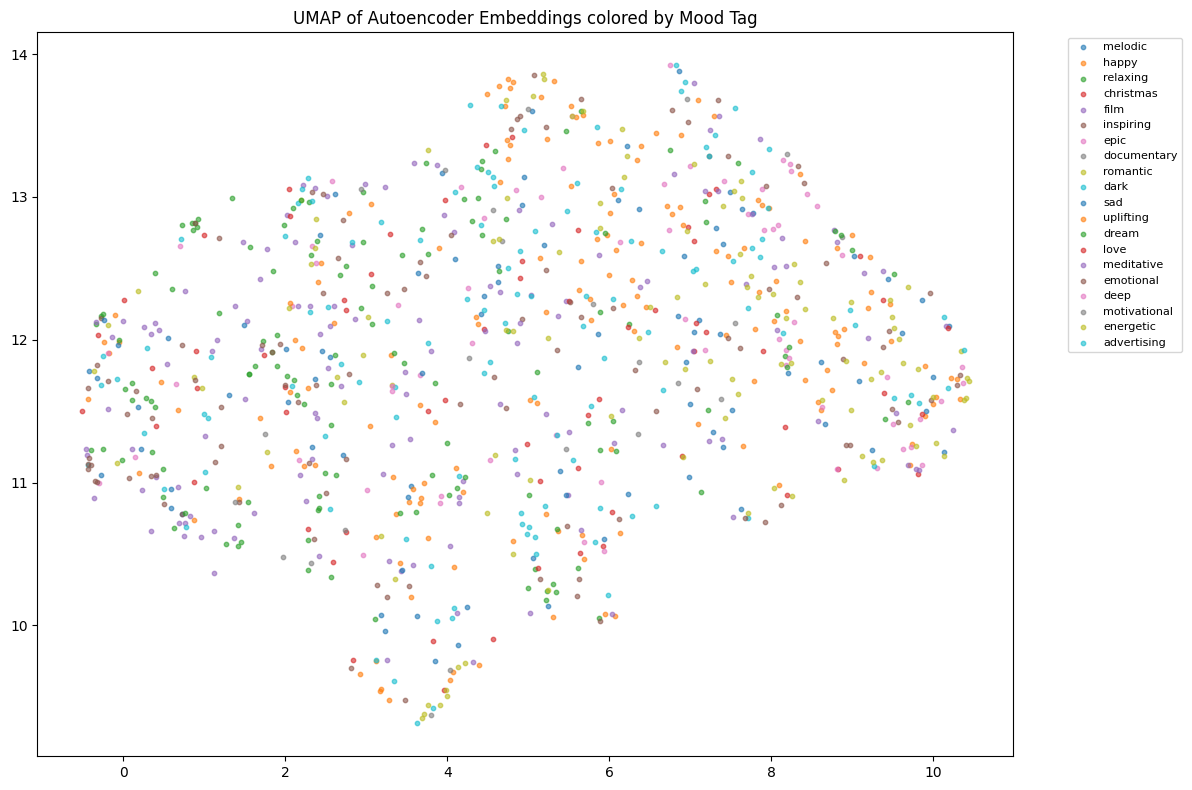

Running PCA...
Variance explained: 56.1%


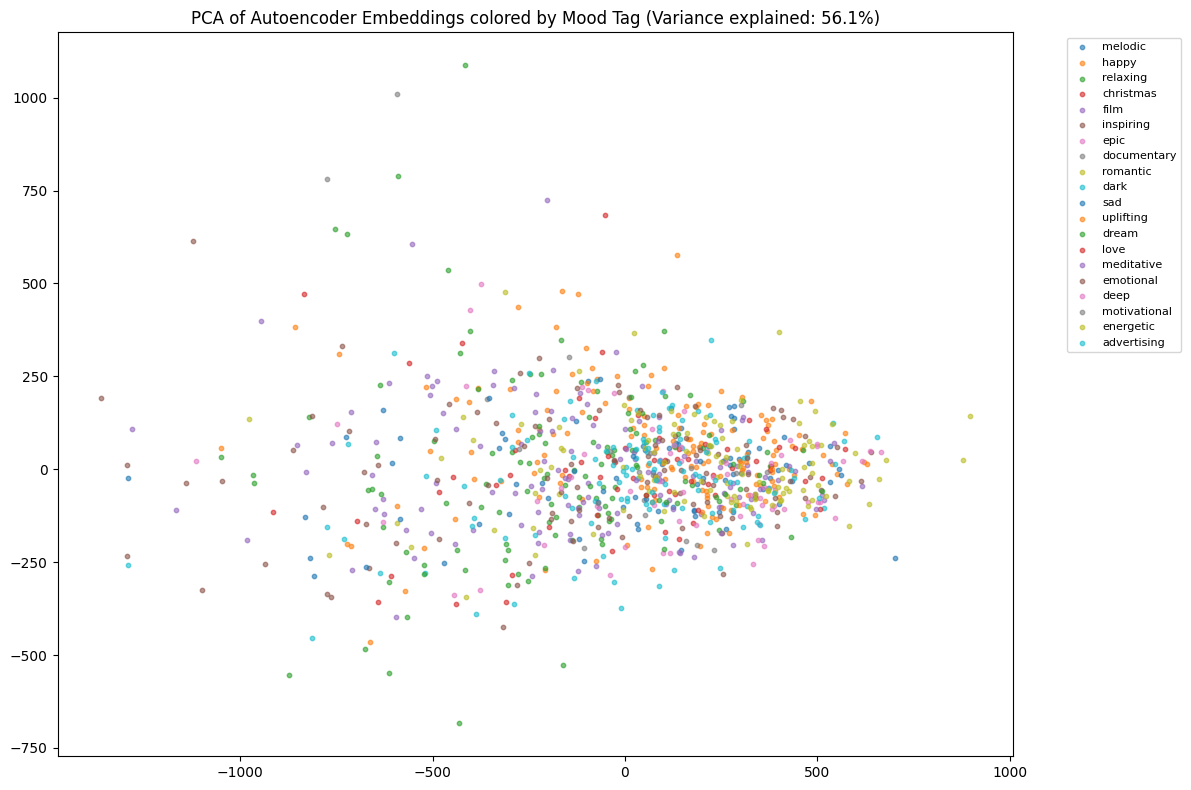

In [15]:
!pip install umap-learn -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import umap
from sklearn.decomposition import PCA

# --- Step 1: Extract all embeddings ---
model.eval()
all_embeddings = []
all_labels     = []
all_tags       = []

with torch.no_grad():
    for mels, labels in tqdm(test_loader, desc="Extracting embeddings"):
        mels = mels.to(device)
        z = model.encode(mels)
        all_embeddings.append(z.cpu().numpy())
        all_labels.append(labels.numpy())

all_embeddings = np.concatenate(all_embeddings, axis=0)  # (N, 128)
all_labels     = np.concatenate(all_labels,     axis=0)  # (N, 20)

print(f"Embeddings shape: {all_embeddings.shape}")

# --- Step 2: Assign primary tag per track for coloring ---
# Use the first (strongest) tag for tracks with multiple tags
primary_tag_idx = np.argmax(all_labels, axis=1)
primary_tag_names = [top_tags[i] for i in primary_tag_idx]

# Color map
unique_tags = list(set(primary_tag_names))
colors = cm.tab20(np.linspace(0, 1, len(unique_tags)))
tag_to_color = {tag: colors[i] for i, tag in enumerate(unique_tags)}
point_colors = [tag_to_color[t] for t in primary_tag_names]

# --- Step 3: UMAP ---
print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42)
umap_emb = reducer.fit_transform(all_embeddings)

plt.figure(figsize=(12, 8))
for tag in unique_tags:
    mask = [t == tag for t in primary_tag_names]
    plt.scatter(
        umap_emb[mask, 0], umap_emb[mask, 1],
        label=tag.replace('mood/theme---', ''),
        alpha=0.6, s=10
    )
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.title('UMAP of Autoencoder Embeddings colored by Mood Tag')
plt.tight_layout()
plt.show()

# --- Step 4: PCA ---
print("Running PCA...")
pca = PCA(n_components=2)
pca_emb = pca.fit_transform(all_embeddings)
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(12, 8))
for tag in unique_tags:
    mask = [t == tag for t in primary_tag_names]
    plt.scatter(
        pca_emb[mask, 0], pca_emb[mask, 1],
        label=tag.replace('mood/theme---', ''),
        alpha=0.6, s=10
    )
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.title(f'PCA of Autoencoder Embeddings colored by Mood Tag (Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%)')
plt.tight_layout()
plt.show()

Mounted at /content/drive
Drive mounted and metadata found. Ready to go.
Melspec files on Drive: 13880


Copying 5000 files...


Copying: 100%|██████████| 5000/5000 [08:05<00:00, 10.31it/s]

Done! Files available: 5000


0 corrupted files found.
All files OK.


,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS_MOOD
0,track_0000948,artist_000087,album_000149,48/948.mp3,212.7,[mood/theme---background]
1,track_0000950,artist_000087,album_000149,50/950.mp3,248.0,[mood/theme---background]
2,track_0000951,artist_000087,album_000149,51/951.mp3,199.7,[mood/theme---background]
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,[mood/theme---film]
4,track_0002263,artist_000320,album_000366,63/2263.mp3,494.7,[mood/theme---melancholic]


Filtered dataset: 13881 tracks


,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS_MOOD
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,[mood/theme---film]
5,track_0003346,artist_000517,album_000521,46/3346.mp3,195.0,[mood/theme---melodic]
6,track_0003347,artist_000517,album_000521,47/3347.mp3,201.8,[mood/theme---melodic]
7,track_0003348,artist_000517,album_000521,48/3348.mp3,253.3,[mood/theme---melodic]
8,track_0003349,artist_000517,album_000521,49/3349.mp3,228.4,[mood/theme---melodic]


,TRACK_ID,ARTIST_ID,ALBUM_ID,PATH,DURATION,TAGS_MOOD,LABEL_ENCODING
3,track_0002165,artist_000326,album_000347,65/2165.mp3,229.0,[mood/theme---film],"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,track_0003346,artist_000517,album_000521,46/3346.mp3,195.0,[mood/theme---melodic],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
6,track_0003347,artist_000517,album_000521,47/3347.mp3,201.8,[mood/theme---melodic],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
7,track_0003348,artist_000517,album_000521,48/3348.mp3,253.3,[mood/theme---melodic],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
8,track_0003349,artist_000517,album_000521,49/3349.mp3,228.4,[mood/theme---melodic],"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."


Available tracks with local npy: 5000
Train: 3200 | Val: 800 | Test: 1000
